In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

In [45]:
def load_data():
    """
    Load the training data from file.

    Reads data from the file `../lab_2/trainData.txt`, converts features to
    np.float64 and labels to np.int64, and returns transposed features and labels.

    Returns:
        X (ndarray): Transposed feature matrix.
        y (ndarray): Label array.
    """
    # File path with training data from `../lab_2/trainData.txt`
    path = '../lab_2/trainData.txt'
    data = []
    # Read the data from file, splitting each line by comma
    with open(path, 'r') as f:
        for line in f:
            data.append(line.split(','))
    data = np.array(data)
    # Convert features and labels to appropriate data types
    X = data[:, :-1].astype(np.float64).T
    y = data[:, -1].astype(np.int64)
    return X, y

# Load data and print to confirm contents
X, y = load_data()
print(X, y)

[[ 1.85284048 -0.21530775  0.04653456 ... -0.06393955  1.06665359
  -0.47186462]
 [-0.16436898  1.63665974 -1.16487257 ... -0.92205024  3.27717415
  -0.37118987]
 [ 1.09839078 -0.61831145  0.04392191 ...  1.65445602 -0.53087884
  -1.04041218]
 [-0.93073689  0.99002204 -0.41369086 ... -1.527528    1.42338924
  -0.253746  ]
 [-1.0193342   0.38670252 -1.08847926 ...  1.87609599 -1.11381038
  -0.02120134]
 [ 1.16696309  1.15926273 -1.37988988 ...  0.75929015 -0.15047129
  -1.4376229 ]] [1 0 1 ... 1 0 0]


In [46]:
def split_data(X, y, seed=0):
    """
    Split the dataset into training and testing sets.

    Randomly shuffles the dataset using the provided seed and splits it into
    training and testing parts, with training comprising two-thirds of data.

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Label vector.
        seed (int): Random seed for reproducibility.

    Returns:
        tuple: ((X_train, y_train), (X_test, y_test))
    """
    # Initialize random seed and generate permutation indices
    np.random.seed(seed)
    idx = np.random.permutation(X.shape[1])
    nTrain = int(X.shape[1] * 2/3)
    # Divide indices for training and testing sets
    idxTrain = idx[:nTrain]
    idxTest  = idx[nTrain:]
    return (X[:, idxTrain], y[idxTrain]), (X[:, idxTest], y[idxTest])

In [47]:
def estimatePCA(X, m):
    """
    Estimate the top m principal components using PCA.

    Centers the data, computes the covariance matrix, performs eigen-decomposition,
    and selects the m principal directions (eigenvectors).

    Parameters:
        X (ndarray): Original feature matrix.
        m (int): Number of principal components to estimate.

    Returns:
        P (ndarray): Matrix of principal components (features x m).
        mu (ndarray): Mean of the original data used for centering.
    """
    # Compute mean and center data
    mu = np.mean(X, axis=1, keepdims=True)
    X_centered = X - mu
    # Compute covariance matrix and eigen-decomposition
    C = np.dot(X_centered, X_centered.T) / X.shape[1]
    eigvals, eigvecs = np.linalg.eigh(C)
    # Order eigenvectors in descending order and select top m
    P = eigvecs[:, ::-1][:, :m]
    return P, mu

def applyPCA(P, X, mu):
    """
    Apply PCA projection to the data.

    Projects data on the PCA space using the provided principal components.

    Parameters:
        P (ndarray): Principal components matrix.
        X (ndarray): Data to be projected.
        mu (ndarray): Mean vector used to center the data.

    Returns:
        ndarray: Projected data.
    """
    # Project centered data on the principal component space
    return np.dot(P.T, X - mu)

# Compute PCA and project original data
P, mu = estimatePCA(X, 6)
X_pca = applyPCA(P, X, mu)


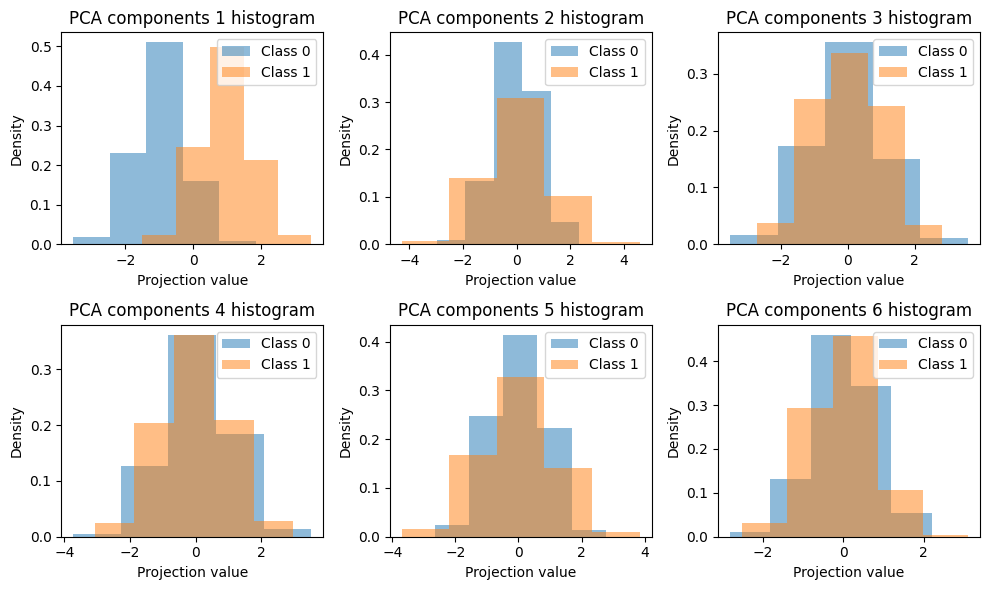

In [48]:
def plot_pca_histograms(X_pca, y, num_components=6):
    """
    Plot histograms of PCA components arranged in a 2x3 grid.

    Creates subplots for each PCA component, displaying the distribution
    for each class in a histogram.

    Parameters:
        X_pca (ndarray): Projected data from PCA.
        y (ndarray): Class labels.
        num_components (int): Maximum number of PCA components to plot.
    """
    # Get unique classes in the dataset
    classes = np.unique(y)
    # Create a 2x3 grid for subplots
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.flatten()

    n_components = min(num_components, X_pca.shape[0])
    # Plot histogram for each PCA component
    for i in range(n_components):
        ax = axes[i]
        for c in classes:
            # Plot histogram for elements belonging to a particular class
            ax.hist(X_pca[i, y == c], bins=5, alpha=0.5, label=f'Class {c}', density=True)
        ax.set_title(f'PCA components {i+1} histogram')
        ax.set_xlabel('Projection value')
        ax.set_ylabel('Density')
        ax.legend()

    # Remove unused subplots if any remain
    for j in range(n_components, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot PCA histograms
plot_pca_histograms(X_pca, y)


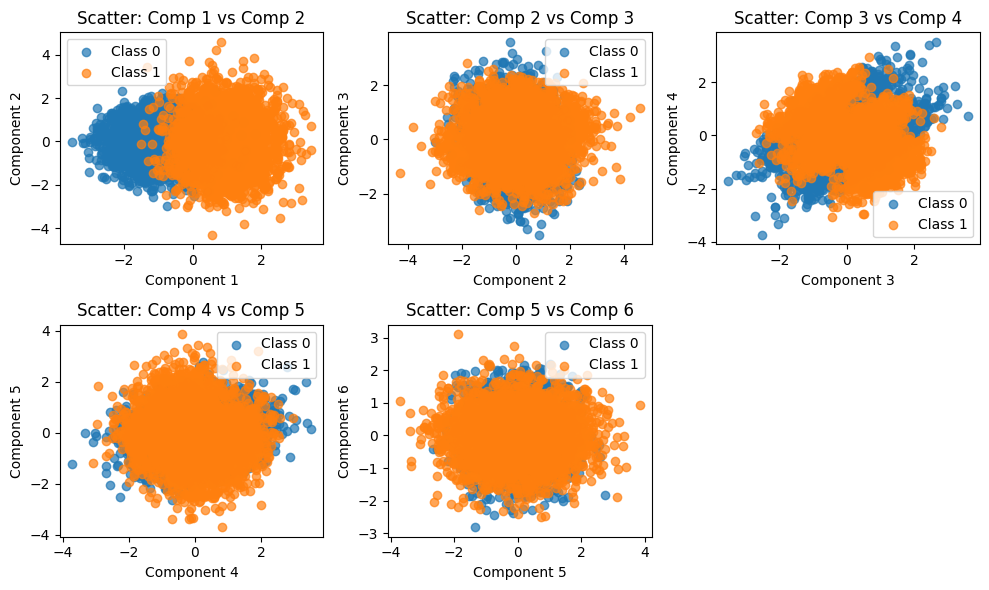

In [49]:
def plot_scatter_grid(X, y):
    """
    Plot scatter plots for consecutive pairs of projected data components
    arranged on a fixed 2x3 grid.

    The function plots component i versus component i+1 for up to 6 pairs.
    Unused subplots are removed if there are fewer than 6 pairs.

    Parameters:
        X (ndarray): Projected data array of shape (d, n_samples), where d >= 2.
        y (ndarray): Class label array.
    """
    classes = np.unique(y)
    # Number of consecutive pairs available
    n_pairs = min(6, X.shape[0] - 1)

    # Create a fixed 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.flatten()

    for i in range(n_pairs):
        ax = axes[i]
        # Scatter plot for component i (x axis) vs component i+1 (y axis)
        for c in classes:
            idx = (y == c)
            ax.scatter(X[i, idx], X[i+1, idx], alpha=0.7, label=f'Class {c}')
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}')
        ax.set_title(f'Scatter: Comp {i+1} vs Comp {i+2}')
        ax.legend()

    # Remove unused subplots if any.
    for j in range(n_pairs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_scatter_grid(X_pca, y)

In [50]:
def estimateLDA(X, y):
    """
    Estimate the Linear Discriminant Analysis (LDA) projection vector.

    Computes the total mean, class means, and calculates the within-class (SW)
    and between-class (SB) scatter matrices. Solves the generalized eigenvalue problem
    to obtain the projection vector and adjusts its orientation.

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Label vector.

    Returns:
        W (ndarray): Projection vector for LDA (features x 1).
    """
    # Compute overall mean and per-class means and counts
    overall_mean = np.mean(X, axis=1, keepdims=True)
    classes = np.unique(y)
    means = {c: np.mean(X[:, y == c], axis=1, keepdims=True) for c in classes}
    counts = {c: X[:, y == c].shape[1] for c in classes}
    N = X.shape[1]

    # Compute within-class scatter matrix (SW)
    SW = np.zeros((X.shape[0], X.shape[0]))
    for c in classes:
        Xc = X[:, y == c]
        Xc_centered = Xc - means[c]
        SW += Xc_centered @ Xc_centered.T
    SW = SW / N

    # Compute between-class scatter matrix (SB)
    SB = np.zeros((X.shape[0], X.shape[0]))
    for c in classes:
        diff = means[c] - overall_mean
        SB += counts[c] * (diff @ diff.T)
    SB = SB / N

    # Solve generalized eigenvalue problem for SB and SW
    s, U = scipy.linalg.eigh(SB, SW)
    # Select the eigenvector corresponding to the largest eigenvalue
    W = U[:, ::-1][:, 0:1]

    # Adjust orientation: ensure class 2's projected mean is greater than class 1's
    X_lda = W.T @ X
    if np.mean(X_lda[0, y == 1]) > np.mean(X_lda[0, y == 2]):
        W = -W
    return W